# G_1 — Figure 1b: map of the investment portfolio

**Input:** `Results/06.xlsx`, GISCO country geometries
**Output:** Figure 1b

Plots investments with resolved coordinates at both ends, distinguishing
delayed from on-schedule. Investments with ambiguous or offshore locations are
excluded rather than approximated.

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import kaleido
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
import matplotlib as mpl
import seaborn as sns

In [2]:
df = pd.read_excel("Results/06.xlsx", header=[0,1], index_col=0)

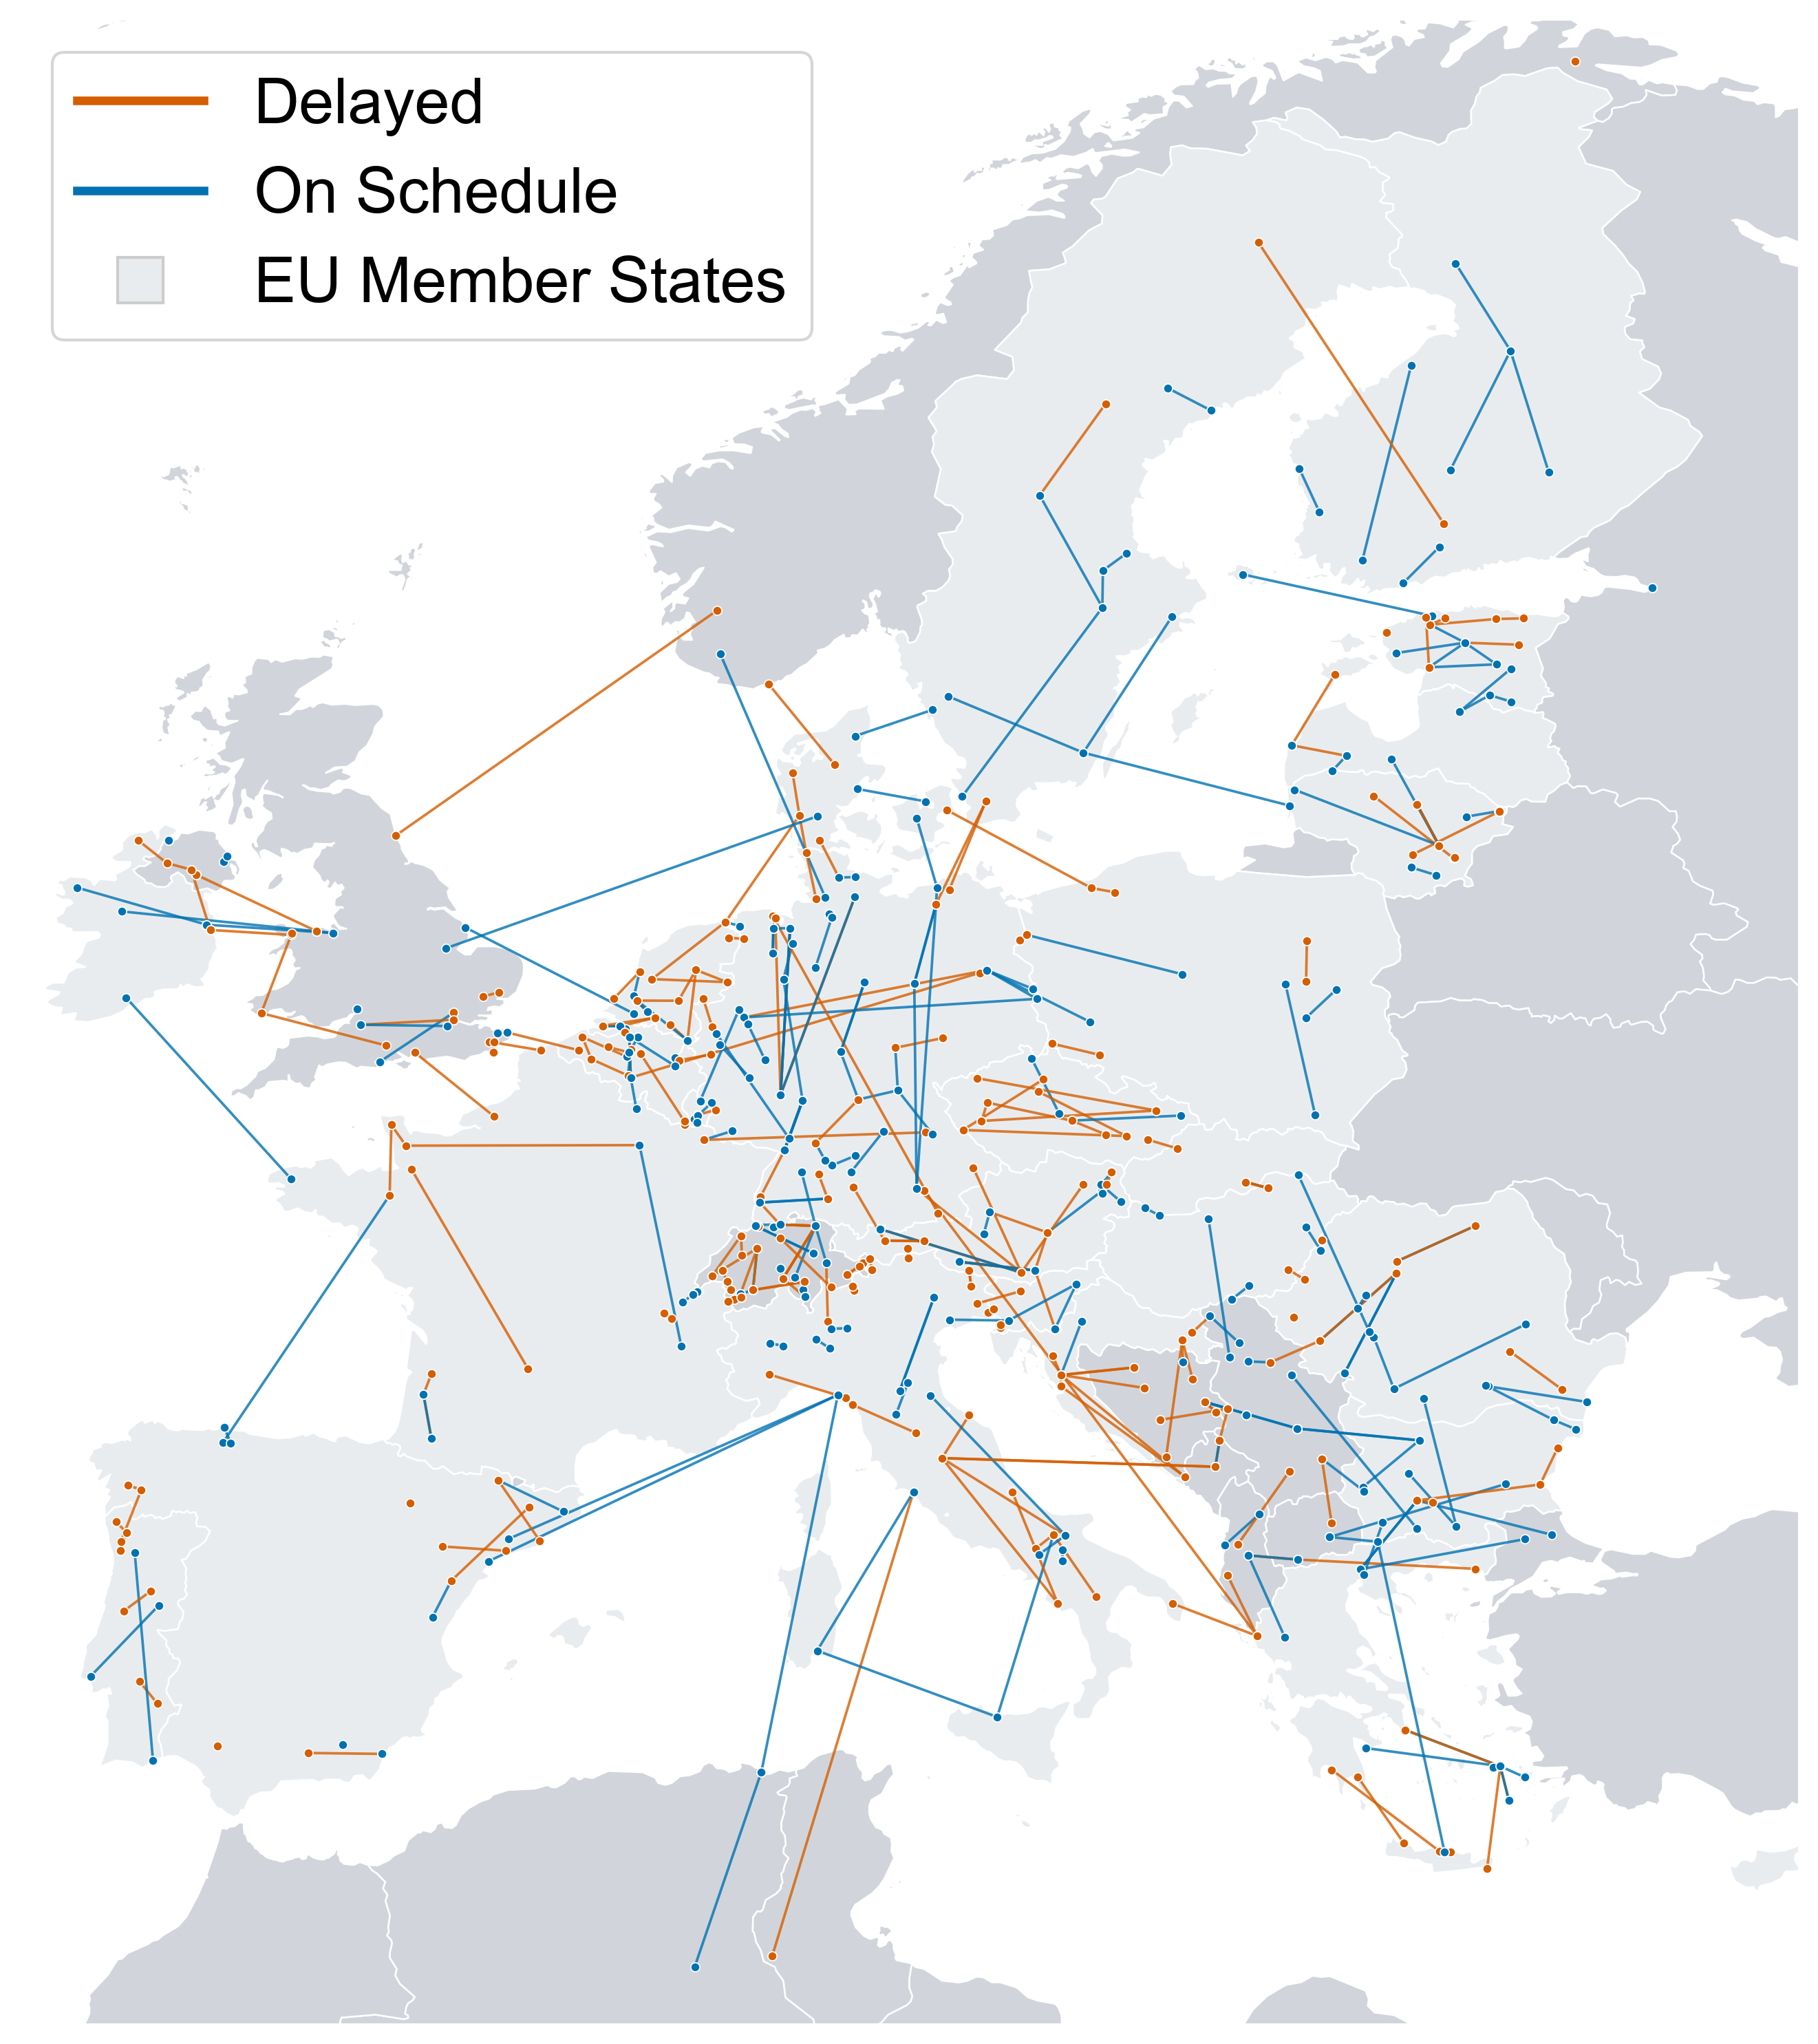

In [3]:

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42  
mpl.rcParams['ps.fonttype'] = 42

eu_iso3 = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 
    'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 
    'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE'
]


world_url = "https://gisco-services.ec.europa.eu/distribution/v2/countries/geojson/CNTR_RG_10M_2020_4326.geojson"

try:
    world = gpd.read_file(world_url)
    world['is_eu'] = world['ISO3_CODE'].isin(eu_iso3)
except Exception as e:
    print(f"Errore caricamento mappa: {e}")
    world = None


plot_df = df[
    df[('meta', 'Inv_From_Lat')].notna() & 
    df[('meta', 'Inv_To_Lat')].notna()
].copy()


fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
ax.set_facecolor('#ffffff') # Oceano bianco puro


if world is not None:
    # Extra-EU
    world[~world['is_eu']].plot(ax=ax, color='#D1D5DB', edgecolor='#ffffff', linewidth=0.6, zorder=1)
    # EU
    world[world['is_eu']].plot(ax=ax, color='#E9ECEF', edgecolor='#ffffff', linewidth=0.6, zorder=1)


for idx, row in plot_df.iterrows():
    lat_f, lon_f = row[('meta', 'Inv_From_Lat')], row[('meta', 'Inv_From_Lon')]
    lat_t, lon_t = row[('meta', 'Inv_To_Lat')], row[('meta', 'Inv_To_Lon')]
    
    delay = row[('meta', 'delay')]
    status_color = '#D55E00' if delay > 0 else '#0072B2' 
    
    # Lines
    ax.plot([lon_f, lon_t], [lat_f, lat_t], 
            color=status_color, linewidth=0.9, alpha=0.8, zorder=2)
    
    # Nodes
    ax.scatter([lon_f, lon_t], [lat_f, lat_t], 
               color=status_color, s=10, edgecolors='white', linewidths=0.4, zorder=3)


ax.set_aspect(1.3)
ax.set_xlim(-11, 34)  
ax.set_ylim(32, 71) 


legend_elements = [
    Line2D([0], [0], color='#D55E00', lw=3, label='Delayed'),
    Line2D([0], [0], color='#0072B2', lw=3, label='On Schedule'),
    Line2D([0], [0], marker='s', color='w', label='EU Member States', 
           markerfacecolor='#E9ECEF', markeredgecolor='#CCCCCC', markersize=16),
]

ax.legend(handles=legend_elements, loc='upper left', frameon=True, 
          facecolor='white', edgecolor='#CCCCCC', shadow=False, fontsize=22)

ax.axis('off')
plt.tight_layout()

plt.savefig("Images/Investments_map_slide.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.savefig("Images/Investments_map_slide.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()